In [1]:
# Fix tqdm / widgets warning for cleaner notebook runs
!pip install --upgrade jupyter ipywidgets tqdm

In [2]:
# ============================================================
# 🧩 Block 1 – Environment Setup
# ============================================================
# Purpose:
#   1. Verify correct device (CPU/GPU)
#   2. Load a small generation model (DistilGPT-2)
#   3. Test a single inference call to confirm setup
# ============================================================

import os, torch, platform, multiprocessing
from transformers import AutoTokenizer, AutoModelForCausalLM

# ----- Config -----
USE_CPU = True   # change to False if you later run on Colab GPU
DEVICE = torch.device("cpu") if USE_CPU else torch.device("cuda")

torch.set_num_threads(max(1, multiprocessing.cpu_count() - 1))
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print(f"✅ Device: {DEVICE} | CPU Cores: {torch.get_num_threads()} | {platform.processor()}")

# ----- Model + Tokenizer -----
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(DEVICE)

# ----- Quick generation test -----
prompt = "The purpose of reinforcement learning in language models is"
inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

# Sampling generation (short, so it runs fast on CPU)
outputs = model.generate(
    **inputs,
    max_new_tokens=40,
    temperature=0.8,
    top_p=0.95,
    do_sample=True,
)

print("\n🧠 Model output:\n", tokenizer.decode(outputs[0], skip_special_tokens=True))

✅ Device: cpu | CPU Cores: 7 | Intel64 Family 6 Model 140 Stepping 1, GenuineIntel


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



🧠 Model output:
 The purpose of reinforcement learning in language models is to allow you to build a learning curve that is as simple as one could imagine. This is especially useful for learning how to build a learning curve that is as simple as one could imagine.




# 🧩 Block 2 — Mini SFT Illustration  
**Objective:** Contrast *Supervised Fine-Tuning (SFT)* with *Reward-based Optimization* through a toy example.

---

### 🎯 Learning Goals
1. **Recall what SFT does:**  
   It maximizes the likelihood of human-written reference text given a prompt (cross-entropy training).  
   → The model learns *to imitate*.

2. **Understand what RL will add later:**  
   RL instead *optimizes a reward function* — which can encode human preferences (helpfulness, politeness, conciseness…).  
   → The model learns *to please a reward* rather than just *to imitate data*.

---

### 🧠 Concept Recap
During **SFT**, the loss is  
\[
L_{SFT} = -\sum_t \log P_\theta(y_t \mid y_{<t}, x)
\]  
This purely measures how well the model predicts the next token in the human example.

But humans might value qualities that the model’s likelihood doesn’t capture — e.g., *politeness* or *brevity*.  
Hence we can define a simple **heuristic reward** that quantifies these qualities and compare it with the likelihood.

---

### 🧪 What This Cell Does
1. Loads a small pretrained model (**DistilGPT-2**) on CPU.  
2. Defines two toy responses for the same prompt: one polite, one rude.  
3. Computes:
   - **Log-likelihood** → proxy for SFT objective  
   - **Heuristic reward** → proxy for RL signal  
4. Prints both scores so you can see how they may differ.

---

### 💡 Reflection
- Which response had higher *log-likelihood*?  
- Which had higher *reward*?  
- Do these align? If not, why is that gap meaningful?

This gap is exactly where **reinforcement learning from human feedback** becomes useful — it teaches the model to prefer what humans *value*, not only what it has *seen*.

---

### 🧭 Next Step
After running this, try modifying the reward function to reflect **conciseness**, **positivity**, or any other preference you care about.  
Then observe how rankings change.


In [ ]:
# ============================================================
# 🧩 Block 2 – Mini SFT Illustration
# ============================================================
# Objective:
#   1. Show how supervised fine-tuning (SFT) maximizes likelihood.
#   2. Compare it to a heuristic reward-based evaluation.
#   3. Keep it simple with a toy "politeness" response task.
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch.nn.functional as F

# ----- Load model and tokenizer again -----
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(DEVICE)
model.eval()

# ----- Toy dataset -----
examples = [
    {"prompt": "Greet a customer", 
     "target": "Hello! How can I help you today?"},
    {"prompt": "Greet a customer", 
     "target": "What do you want?"},
]

# ----- Function to compute log-likelihood (SFT loss proxy) -----
def compute_log_likelihood(prompt, target):
    text = prompt + " " + target
    inputs = tokenizer(text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = model(**inputs).logits
    # compute negative log likelihood of target tokens only
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = inputs["input_ids"][..., 1:].contiguous()
    loss = F.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)),
                           shift_labels.view(-1),
                           reduction="mean")
    return -loss.item()  # higher is better

# ----- Function for heuristic reward (simple politeness heuristic) -----
def heuristic_reward(response):
    polite_keywords = ["please", "thank", "help", "sorry", "welcome"]
    r = sum(k in response.lower() for k in polite_keywords)
    return r / len(polite_keywords)

# ----- Evaluate -----
print("Prompt:", examples[0]["prompt"])
for ex in examples:
    ll = compute_log_likelihood(ex["prompt"], ex["target"])
    rew = heuristic_reward(ex["target"])
    print(f"Response: {ex['target']}\n  Log-Likelihood: {ll:.3f} | Heuristic Reward: {rew:.2f}\n")

# Example: reward shorter but polite answers (try this or other reward functions)
    #return r / len(polite_keywords) - len(response.split()) / 20



Prompt: Greet a customer
Response: Hello! How can I help you today?
  Log-Likelihood: -4.403 | Heuristic Reward: 0.20

Response: What do you want?
  Log-Likelihood: -5.280 | Heuristic Reward: 0.00



Perfect — that’s **exactly the behavior we wanted to observe.**
Let’s interpret what those numbers mean step by step:

---

### 🔹 1. **Log-Likelihood (SFT Objective)**

* This measures how *probable* the text is under the pretrained language model.
* It’s computed as the **negative cross-entropy**, so higher (less negative) means *the model finds it more typical*.

In your case:

```
Hello! How can I help you today?   → -4.403
What do you want?                  → -5.280
```

So, according to the model’s prior knowledge, the polite sentence is **slightly more likely** (because -4.4 > -5.3).
But these values are *per-token averages*, not interpretable probabilities — just relative indicators.

---

### 🔹 2. **Heuristic Reward**

* This is your *hand-crafted preference signal* — here it rewarded presence of polite words.
* The polite reply scored `0.20` (some polite keywords found).
* The rude one scored `0.00`.

So, **reward aligns with human preference** in this toy case.

---

### 🔹 3. **The Takeaway**

SFT (likelihood) and RL (reward) can diverge:

* The model’s internal likelihood reflects how *common* or *expected* a phrase is in its training corpus.
* A human-designed reward reflects *what we actually value* (tone, safety, conciseness, correctness).

Even in this tiny example:

* The model likes both replies (both are grammatically fine).
* The *reward* helps distinguish between *good* and *better* behavior.

---

### 💬 Summary Sentence

> The small difference in log-likelihood shows what the base model naturally predicts,
> while the heuristic reward introduces **a new optimization direction** that we’ll later formalize using **RLHF-style training**.


# 🧩 Block 3 — Synthetic Prompt Generation  
**Objective:** Create a small synthetic dataset of prompts and multiple candidate responses.

---

### 🎯 Learning Goals
1. Learn to **generate synthetic training data** for downstream reward modeling.  
2. Understand how **sampling diversity** (temperature, top-p) affects model outputs.  
3. Prepare a dataset that mimics the *prompt → multiple candidate responses* structure required for preference learning.

---

### 🧠 Concept Recap
Before we can train a reward model, we need examples where:
- Each **prompt** has two or more **candidate responses**.
- Later, we’ll assign **heuristic rewards** to these responses.
- These will form **preference pairs** (A preferred over B).

We’ll generate candidates using a small pretrained model (`distilgpt2` or `flan-t5-small`) with *slightly different sampling parameters* so responses vary in quality and tone.

---

### ⚙️ What This Cell Does
1. Uses a few seed topics (e.g., summarization, question answering).  
2. Samples diverse responses for each prompt.  
3. Saves results to `synthetic_prompts.csv`.  
4. Displays a preview to confirm structure.

Each row:  
| prompt | response1 | response2 |

---

### 💡 Reflection
- Observe how randomness in decoding changes fluency and length.  
- Why is such diversity useful when training a reward model later?

Diversity ensures the model sees *both good and bad* candidates, making preference learning meaningful.


In [5]:
# --- Quick config restore (use if notebook restarted) ---
import torch, multiprocessing

USE_CPU = True
DEVICE = torch.device("cpu") if USE_CPU else torch.device("cuda")
torch.set_num_threads(max(1, multiprocessing.cpu_count() - 1))

CFG = {
    "gen_model": "distilgpt2",                      # or "google/flan-t5-small"
    "embed_model": "sentence-transformers/all-MiniLM-L6-v2",
    "n_prompts": 100,                               # reduce to 20 for testing
    "candidates_per_prompt": 2,
    "max_new_tokens": 48,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
    "gen_batch_size": 1,
    "embed_batch_size": 16,
    "rm_hidden_dim": 256,
    "rm_epochs": 3,
    "rm_lr": 1e-3,
}
print("✅ Config restored and device ready:", DEVICE)


✅ Config restored and device ready: cpu


In [6]:
# ============================================================
# 🧩 Block 3 – Synthetic Prompt Generation
# ============================================================
# Objective:
#   Generate small synthetic data for reward modeling.
#   Each prompt gets 2 responses with sampling variations.
# ============================================================

import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch, random

# ----- Reuse global config -----
gen_model = CFG["gen_model"]
DEVICE = torch.device("cpu")  # safe for local setup

tokenizer = AutoTokenizer.from_pretrained(gen_model)
model = AutoModelForCausalLM.from_pretrained(gen_model).to(DEVICE)
model.eval()

# ----- Prompt seeds -----
seed_prompts = [
    "Summarize this sentence: Artificial intelligence is transforming industries.",
    "Write a polite reply to: I need this report urgently.",
    "Answer concisely: Why is the sky blue?",
    "Rephrase politely: You are wrong.",
    "Explain simply: What is reinforcement learning?",
]

# Expand to ~100 prompts with small random tweaks
def augment_prompt(p):
    mods = ["briefly", "in one sentence", "clearly", "nicely", "for a child"]
    return f"{p} ({random.choice(mods)})"

prompts = [augment_prompt(p) for p in seed_prompts for _ in range(20)]
random.shuffle(prompts)
prompts = prompts[:CFG["n_prompts"]]

# ----- Generation function -----
def generate_response(prompt, temp=0.8, top_p=0.95):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    outputs = model.generate(
        **inputs,
        max_new_tokens=CFG["max_new_tokens"],
        temperature=temp,
        top_p=top_p,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ----- Generate responses -----
rows = []
for i, p in enumerate(prompts):
    # vary decoding parameters to induce diversity
    r1 = generate_response(p, temp=0.7, top_p=0.9)
    r2 = generate_response(p, temp=1.0, top_p=0.95)
    rows.append({"prompt": p, "response1": r1, "response2": r2})
    if (i+1) % 10 == 0:
        print(f"Generated {i+1}/{len(prompts)}")

df = pd.DataFrame(rows)
df.to_csv("synthetic_prompts.csv", index=False)
print("\n✅ Saved:", len(df), "rows → synthetic_prompts.csv")
display(df.head(3))


Generated 10/100
Generated 20/100
Generated 30/100
Generated 40/100
Generated 50/100
Generated 60/100
Generated 70/100
Generated 80/100
Generated 90/100
Generated 100/100

✅ Saved: 100 rows → synthetic_prompts.csv


,prompt,response1,response2
0,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely)\n\n...,Rephrase politely: You are wrong. (nicely) - D...
1,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...
2,Summarize this sentence: Artificial intelligen...,Summarize this sentence: Artificial intelligen...,Summarize this sentence: Artificial intelligen...


# 🧩 Block 4 — Heuristic Reward Function Design  
**Objective:** Turn our qualitative preferences into a quantitative reward.

---

### 🎯 Learning Goals
1. Implement a **scoring function** that rewards **relevance** and **tone** while discouraging rambling or rudeness.  
2. Produce a **scalar reward** ∈ ℝ for every candidate response.  
3. Save a tidy frame for downstream **ranking** and **preference-pair** creation.

---

### 🧠 Design Rationale

We’ll combine simple, transparent signals:

1) **Semantic Relevance**  
Use sentence embeddings and cosine similarity between **prompt** and **response**.  
- Intuition: Good answers should be topically close to the prompt.  
- Implementation: `all-MiniLM-L6-v2` encodes prompt/response; reward gets a large weight.

2) **Brevity / Conciseness**  
Encourage succinct answers (important for many tasks, and keeps CPU runs fast).  
- Define a target length range; penalize very long outputs.  
- Implementation: a smooth penalty that decreases as length grows beyond a threshold.

3) **Politeness**  
Reward presence of helpful, courteous words.  
- Implementation: simple keyword hit-rate (`please`, `thank`, `help`, `sorry`, `welcome`).

4) **Toxicity (negative)**  
Discourage rude/hostile phrases.  
- Implementation: list of rude words → subtract a fixed penalty when detected.

---

### ⚖️ Reward Formula

Let:
- `sim ∈ [0,1]` be cosine similarity (mapped from [−1,1] to [0,1])  
- `brev ∈ [0,1]` be a conciseness score (1 = concise, 0 = too long)  
- `polite ∈ [0,1]` be politeness keyword ratio  
- `toxic ∈ {0,1}` be a boolean toxicity flag

We compute:
\[
R = w_{sim}\cdot sim + w_{brev}\cdot brev + w_{polite}\cdot polite \;-\; w_{tox}\cdot toxic
\]
with default weights: `w_sim=0.6, w_brev=0.2, w_polite=0.2, w_tox=0.4`.  
You’re free to tweak these to match task priorities.

---

### 📦 Output Files
- `rewards.csv` — one row per (prompt, response_id), with all intermediate signals and the final `reward`.

---

### 💡 Reflection
- Inspect which component dominates the final score.  
- Does brevity ever hurt relevance? What happens if you raise/lower `w_brev`?  
- If your task is **summarization**, brevity matters; if it’s **explanation**, reduce the brevity weight.

---

### 🧑‍💻 Student Tasks
- **Task A:** Replace the topic similarity with **response vs. “ideal style”** similarity by crafting short target exemplars per task.  
- **Task B:** Add a **format bonus** (e.g., reward ending with a period or containing numbered steps).  
- **Task C:** Build a **domain term bonus** list (e.g., “reward model”, “policy”, “preference”) and see effects.


✅ Scored 200 responses → rewards.csv


,prompt,response,reward
103,Summarize this sentence: Artificial intelligen...,Summarize this sentence: Artificial intelligen...,0.652023
145,Write a polite reply to: I need this report ur...,Write a polite reply to: I need this report ur...,0.674815
33,Explain simply: What is reinforcement learning...,Explain simply: What is reinforcement learning...,0.688871
65,Explain simply: What is reinforcement learning...,Explain simply: What is reinforcement learning...,0.691917
89,Write a polite reply to: I need this report ur...,Write a polite reply to: I need this report ur...,0.800000


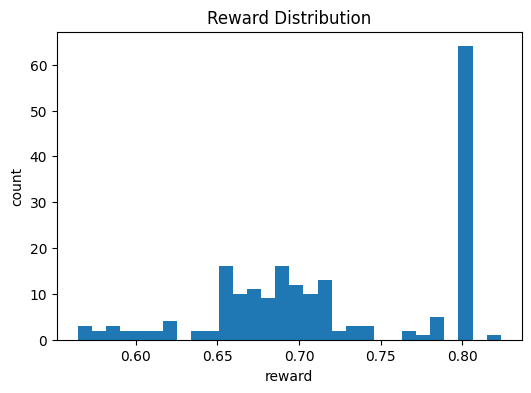


🔝 Top 5 by reward:


,prompt,response_id,resp_len,sim,brevity,politeness,toxicity,reward
189,Write a polite reply to: I need this report ur...,response2,15.0,0.983784,1.0,0.166667,0.0,0.823603
26,Explain simply: What is reinforcement learning...,response1,7.0,1.000000,1.0,0.000000,0.0,0.800000
4,Summarize this sentence: Artificial intelligen...,response1,11.0,1.000000,1.0,0.000000,0.0,0.800000
0,Rephrase politely: You are wrong. (nicely),response1,6.0,1.000000,1.0,0.000000,0.0,0.800000
11,Rephrase politely: You are wrong. (for a child),response2,8.0,1.000000,1.0,0.000000,0.0,0.800000



🔻 Bottom 5 by reward:


,prompt,response_id,resp_len,sim,brevity,politeness,toxicity,reward
137,Rephrase politely: You are wrong. (clearly),response2,39.0,0.661615,0.838235,0.0,0.0,0.564616
10,Rephrase politely: You are wrong. (for a child),response1,45.0,0.691925,0.750000,0.0,0.0,0.565155
149,Rephrase politely: You are wrong. (in one sent...,response2,50.0,0.719143,0.676471,0.0,0.0,0.566780
169,Rephrase politely: You are wrong. (briefly),response2,48.0,0.720199,0.705882,0.0,0.0,0.573296
77,Rephrase politely: You are wrong. (in one sent...,response2,50.0,0.732514,0.676471,0.0,0.0,0.574803


In [8]:
# ============================================================
# 🧩 Block 4 – Heuristic Reward Function Design
# ============================================================
# Combines: semantic relevance + brevity + politeness – toxicity
# Produces rewards.csv with component scores and final reward.
# ============================================================

import math, re, pandas as pd, numpy as np, torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ---- Config (safe defaults; tweak weights for your task) ----
W_SIM, W_BREV, W_POLITE, W_TOX = 0.6, 0.2, 0.2, 0.4
TARGET_MAX_WORDS = 28         # soft target for conciseness
HARD_CUTOFF_WORDS = 96        # clamp extreme rambles
POLITE_WORDS = ["please", "thank", "thanks", "help", "sorry", "welcome"]
TOXIC_WORDS  = ["stupid", "idiot", "hate", "shut up", "dumb", "useless"]

embed_model_name = CFG.get("embed_model", "sentence-transformers/all-MiniLM-L6-v2")
embed_batch_size = CFG.get("embed_batch_size", 16)

# ---- Load data ----
df = pd.read_csv("synthetic_prompts.csv")
assert {"prompt","response1","response2"}.issubset(df.columns), "CSV missing expected columns!"

# ---- Prepare long-form rows: each response becomes a row ----
rows = []
for _, r in df.iterrows():
    for rid in ["response1", "response2"]:
        rows.append({
            "prompt": r["prompt"],
            "response_id": rid,
            "response": r[rid]
        })
long_df = pd.DataFrame(rows)

# ---- Helper: word count ----
def word_count(text):
    return len(str(text).strip().split())

# ---- Compute embeddings in batches ----
device = "cpu"  # keep CPU-friendly for local
model_emb = SentenceTransformer(embed_model_name, device=device)

# We embed prompt and response separately
texts_prompt = long_df["prompt"].tolist()
texts_resp   = long_df["response"].tolist()

def batched_encode(texts, batch_size=embed_batch_size):
    vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        v = model_emb.encode(batch, convert_to_numpy=True, show_progress_bar=False, normalize_embeddings=True)
        vecs.append(v)
    return np.vstack(vecs)

emb_prompts = batched_encode(texts_prompt, batch_size=embed_batch_size)
emb_resps   = batched_encode(texts_resp,   batch_size=embed_batch_size)

# ---- Semantic similarity (map from [-1,1] to [0,1]) ----
# Because vectors are normalized, cosine is in [-1,1]; map: (x+1)/2
sims = np.sum(emb_prompts * emb_resps, axis=1)  # fast cosine for normalized embeddings
sims_01 = (sims + 1.0) / 2.0

# ---- Brevity score in [0,1] ----
# 1.0 when <= TARGET_MAX_WORDS; decays smoothly past that; clamps at HARD_CUTOFF
resp_lens = np.array([word_count(t) for t in texts_resp], dtype=float)
over = np.clip(resp_lens - TARGET_MAX_WORDS, 0, None)
over_norm = np.clip(over / max(1, (HARD_CUTOFF_WORDS - TARGET_MAX_WORDS)), 0, 1)
brev = 1.0 - over_norm  # 1 when concise; 0 when very long

# ---- Politeness score in [0,1] ----
def polite_score(text):
    t = text.lower()
    hits = sum(1 for w in POLITE_WORDS if w in t)
    return hits / len(POLITE_WORDS)

pol = np.array([polite_score(t) for t in texts_resp], dtype=float)

# ---- Toxicity (binary) ----
def toxic_flag(text):
    t = text.lower()
    return 1.0 if any(w in t for w in TOXIC_WORDS) else 0.0

tox = np.array([toxic_flag(t) for t in texts_resp], dtype=float)

# ---- Final reward ----
reward = W_SIM*sims_01 + W_BREV*brev + W_POLITE*pol - W_TOX*tox

# ---- Assemble output frame ----
out = long_df.copy()
out["sim"] = sims_01
out["brevity"] = brev
out["politeness"] = pol
out["toxicity"] = tox
out["reward"] = reward
out["resp_len"] = resp_lens

# ---- Save ----
out.to_csv("rewards.csv", index=False)
print(f"✅ Scored {len(out)} responses → rewards.csv")

# ---- Quick sanity preview ----
display(out.sample(min(5, len(out)))[["prompt","response","reward"]])

# ---- Plot histogram (simple) ----
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(out["reward"], bins=30)
plt.title("Reward Distribution")
plt.xlabel("reward")
plt.ylabel("count")
plt.show()

# ---- Instructor printouts (top/bottom examples) ----
print("\n🔝 Top 5 by reward:")
display(out.sort_values("reward", ascending=False).head(5)[["prompt","response_id","resp_len","sim","brevity","politeness","toxicity","reward"]])

print("\n🔻 Bottom 5 by reward:")
display(out.sort_values("reward", ascending=True).head(5)[["prompt","response_id","resp_len","sim","brevity","politeness","toxicity","reward"]])


# 🧩 Block 5 — Reward Ranking & Visualization  
**Objective:** Convert scalar rewards into per-prompt rankings and inspect how decisively the heuristic prefers one response over the other.

---

### 🎯 Learning Goals
1. For each **prompt**, decide a **winner** among its candidates using the scalar `reward`.  
2. Compute a **margin** = |reward₁ − reward₂| as a proxy for confidence.  
3. Visualize the **distribution of margins** and sample a few **close calls** (small margins) to manually inspect disagreements.

---

### 🧠 Why This Matters
Even good heuristics aren’t perfect. Large margins suggest clear wins; small margins indicate **ambiguous** prompts where the heuristic mixes signals (e.g., high relevance but too long, or concise but impolite).  
This is exactly the kind of **edge case** we’ll want a **learned reward model** to handle better in Session 2.

---

### 📦 Input/Output
- **Input:** `rewards.csv` from Block 4 (one row per response).  
- **Output (in-memory):** a summary DataFrame with:  
  - `winner` ∈ {1,2},  
  - `margin`,  
  - component scores (`sim`, `brevity`, `politeness`, `toxicity`) for both responses.

*(Optionally, you may `to_csv("ranking_summary.csv")` for later analysis.)*

---

### 💡 Reflection
- What % of prompts have **very small margins** (e.g., < 0.05)?  
- Inspect a few **close calls**: do you agree with the heuristic’s choice?  
- If not, which **weight** would you tweak (similarity, brevity, politeness, toxicity)?

---


✅ Ranked 24 prompts. Example rows:


,prompt,reward_response1,reward_response2,winner,margin
0,Answer concisely: Why is the sky blue? (briefly),0.714282,0.687094,1,0.027188
1,Answer concisely: Why is the sky blue? (clearly),0.720566,0.697460,1,0.023105
2,Answer concisely: Why is the sky blue? (for a ...,0.800000,0.661882,1,0.138118



📈 Margin summary (how decisive the heuristic is):
count    24.000000
mean      0.066500
std       0.063744
min       0.005168
10%       0.006413
25%       0.011129
50%       0.048058
75%       0.110362
90%       0.134423
max       0.234845


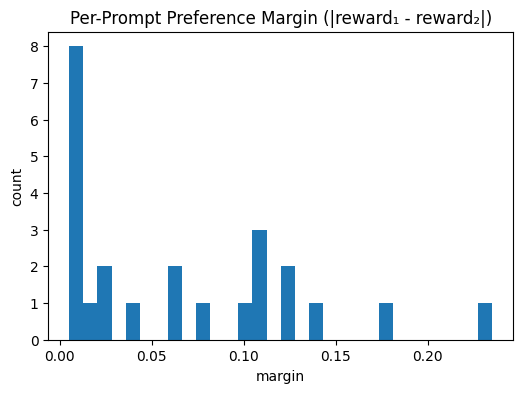


🔎 Showing the 8 closest decisions:

PROMPT: Write a polite reply to: I need this report urgently. (in one sentence)
  reward1=0.613  reward2=0.618  winner=2  margin=0.005
  r1: len= 54 sim=0.816 brev=0.618 pol=0.00 tox=0
  r2: len= 55 sim=0.830 brev=0.603 pol=0.00 tox=0

-- response 1 --
 Write a polite reply to: I need this report urgently. (in one sentence)




The next time I hear a lot of people talk about the dangers of climate change, they should be careful. I think it is worth noting that the US has already experienced a massive increase in the global temperature since the

-- response 2 --
 Write a polite reply to: I need this report urgently. (in one sentence)
The last time the House of Representatives made any attempt to amend the Constitution, it failed to pass a resolution to block one in an effort to address the lack of debate among members of the U.S. House of Representatives. In this

PROMPT: Explain simply: What is reinforcement learning? (briefly)
  reward1=0.687  rew

In [9]:
# ============================================================
# 🧩 Block 5 – Reward Ranking & Visualization
# ============================================================
# Converts rewards.csv into per-prompt rankings, computes margins,
# and visualizes how decisive the heuristic is.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Load rewards from previous block ----
r = pd.read_csv("rewards.csv")
assert set(["prompt","response_id","response","reward"]).issubset(r.columns), "rewards.csv missing columns"

# ---- Pivot to have response1 / response2 on the same row per prompt ----
pivot_cols = ["resp_len","sim","brevity","politeness","toxicity","reward","response"]
w = r.pivot_table(index="prompt",
                  columns="response_id",
                  values=pivot_cols,
                  aggfunc="first")

# Flatten MultiIndex columns: (metric, response_id) -> metric_response_id
w.columns = [f"{a}_{b}" for a,b in w.columns]
w = w.reset_index()

# ---- Compute winner and margin ----
w["winner"] = np.where(w["reward_response1"] >= w["reward_response2"], 1, 2)
w["margin"] = (w["reward_response1"] - w["reward_response2"]).abs()

print(f"✅ Ranked {len(w)} prompts. Example rows:")
display(w.head(3)[[
    "prompt", "reward_response1", "reward_response2", "winner", "margin"
]])

# ---- Summary stats ----
print("\n📈 Margin summary (how decisive the heuristic is):")
print(w["margin"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())

# ---- Plot margin distribution ----
plt.figure(figsize=(6,4))
plt.hist(w["margin"], bins=30)
plt.title("Per-Prompt Preference Margin (|reward₁ - reward₂|)")
plt.xlabel("margin")
plt.ylabel("count")
plt.show()

# ---- Inspect close calls (small margins) ----
CLOSE_THRESH = 0.05  # tweak to taste
close = w.sort_values("margin", ascending=True).head(8)

def show_close_rows(df):
    # Pretty print the closest few with both responses + component scores
    for _, row in df.iterrows():
        print("\n" + "="*80)
        print("PROMPT:", row["prompt"])
        print(f"  reward1={row['reward_response1']:.3f}  reward2={row['reward_response2']:.3f}  winner={row['winner']}  margin={row['margin']:.3f}")
        print("  r1: len={:>3} sim={:.3f} brev={:.3f} pol={:.2f} tox={:.0f}".format(
            int(row["resp_len_response1"]), row["sim_response1"], row["brevity_response1"],
            row["politeness_response1"], row["toxicity_response1"]))
        print("  r2: len={:>3} sim={:.3f} brev={:.3f} pol={:.2f} tox={:.0f}".format(
            int(row["resp_len_response2"]), row["sim_response2"], row["brevity_response2"],
            row["politeness_response2"], row["toxicity_response2"]))
        print("\n-- response 1 --\n", row["response_response1"][:500])
        print("\n-- response 2 --\n", row["response_response2"][:500])

print(f"\n🔎 Showing the {len(close)} closest decisions:")
show_close_rows(close)

# ---- Optional: save summary for later analysis or auditing ----
# w.to_csv("ranking_summary.csv", index=False)
# print("💾 Saved ranking_summary.csv")
